In [1]:
import csv
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [2]:
with open('BBC-News-Train.csv', 'r') as csvfile:
    print(f"Primera Linea : {csvfile.readline()}")
    print(f"Cada fila con datos : {csvfile.readline()}")
    print(f"Cada fila con datos : {csvfile.readline()}")
    print(f"Cada fila con datos : {csvfile.readline()}")

Primera Linea : ArticleId,Text,Category

Cada fila con datos : 1833,worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (Â£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  g

In [3]:
def removeStopwords(sentence):
	stopwords = ["a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as", "at", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "could", "did", "do", "does", "doing", "down", "during", "each", "few", "for", "from", "further", "had", "has", "have", "having", "he", "he'd", "he'll", "he's", "her", "here", "here's", "hers", "herself", "him", "himself", "his", "how", "how's", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "into", "is", "it", "it's", "its", "itself", "let's", "me", "more", "most", "my", "myself", "nor", "of", "on", "once", "only", "or", "other", "ought", "our", "ours", "ourselves", "out", "over", "own", "same", "she", "she'd", "she'll", "she's", "should", "so", "some", "such", "than", "that", "that's", "the", "their", "theirs", "them", "themselves", "then", "there", "there's", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "under", "until", "up", "very", "was", "we", "we'd", "we'll", "we're", "we've", "were", "what", "what's", "when", "when's", "where", "where's", "which", "while", "who", "who's", "whom", "why", "why's", "with", "would", "you", "you'd", "you'll", "you're", "you've", "your", "yours", "yourself", "yourselves" ]
	sentence = sentence.lower()
	sentence = sentence.split(' ')
	for stopword in stopwords:
		try:
			while True:
				sentence.remove(stopword)
		except:
			pass
	sentence = ' '.join(sentence)
	return sentence


In [4]:
def convertirDatosDesdeTexto(archivo):
    sentences = []
    labels = []
    with open(archivo, 'r') as csvfile:
        reader = csv.reader(csvfile, delimiter='\n')
        first = True
        for fila in reader:
            if (first == False):
                texto = fila[0].split(',')
                etiqueta = texto[2]
                labels.append(etiqueta)
                sentences.append(removeStopwords(texto[1]))
            else:
                first = False
    return sentences, labels

In [5]:
sentences, labels = convertirDatosDesdeTexto('BBC-News-Train.csv')

print(f"Cantidad de registros {len(sentences)}")
print(f"Primera oracion : {len(sentences[0].split())}")
print(f"Cantidad de labels : {len(labels)}")

Cantidad de registros 1490
Primera oracion : 203
Cantidad de labels : 1490


In [9]:
def fitTokenizer(sentences):
    tokenizer = Tokenizer(num_words=1000,oov_token="<OOV>")
    tokenizer.fit_on_texts(sentences)
    return tokenizer

In [10]:
tokenizer = fitTokenizer(sentences)
tokenizer.word_index

{'<OOV>': 1,
 's': 2,
 'said': 3,
 'will': 4,
 'not': 5,
 'mr': 6,
 'year': 7,
 'also': 8,
 'new': 9,
 'people': 10,
 'us': 11,
 'one': 12,
 'can': 13,
 'first': 14,
 'last': 15,
 'two': 16,
 'time': 17,
 'world': 18,
 't': 19,
 'now': 20,
 'uk': 21,
 'government': 22,
 'film': 23,
 'years': 24,
 'no': 25,
 'best': 26,
 'just': 27,
 'make': 28,
 'told': 29,
 'three': 30,
 'made': 31,
 'get': 32,
 'game': 33,
 'many': 34,
 'back': 35,
 '000': 36,
 'like': 37,
 'number': 38,
 '1': 39,
 'labour': 40,
 'set': 41,
 'music': 42,
 'next': 43,
 'well': 44,
 'bbc': 45,
 'may': 46,
 'take': 47,
 'added': 48,
 'way': 49,
 'market': 50,
 'election': 51,
 'says': 52,
 'home': 53,
 '2004': 54,
 '2': 55,
 'good': 56,
 'off': 57,
 'england': 58,
 'firm': 59,
 'win': 60,
 'still': 61,
 'top': 62,
 '6': 63,
 'company': 64,
 'blair': 65,
 'show': 66,
 'won': 67,
 'use': 68,
 'week': 69,
 'going': 70,
 'party': 71,
 'second': 72,
 'since': 73,
 'say': 74,
 'games': 75,
 'work': 76,
 'much': 77,
 'million'

In [45]:
def padSequences(tokenizer, sentences):
    sequences = tokenizer.texts_to_sequences(sentences)
    paddedSequences = pad_sequences(sequences, padding='post', maxlen=120)
    return paddedSequences

In [46]:
paddedSequences = padSequences(tokenizer, sentences)

In [47]:
def tokenizerLabels(labels, split_labels):
    labelTokenizer = Tokenizer()
    labelTokenizer.fit_on_texts(labels)
    labelSequences = labelTokenizer.texts_to_sequences(split_labels)
    print(labelTokenizer.word_index)
    labelSequences = np.array(labelSequences)-1
    return labelSequences

In [48]:
def train_val_split(sentences, labels, training_split=0.8):
    train_size = int(len(sentences)*training_split)
    train_sentences = sentences[:train_size]
    train_labels = labels[:train_size]
    val_sentences = sentences[train_size:]
    val_labels = labels[train_size:]
    return train_sentences, val_sentences, train_labels, val_labels

In [49]:
train_sentences, val_sentences, train_labels, val_labels = train_val_split(sentences, labels)

In [50]:
train_pad_seq = padSequences(tokenizer, train_sentences)
val_pad_seq = padSequences(tokenizer, val_sentences)

In [63]:
train_pad_seq[7]

array([  1,   1, 599, 977, 570,   1,   1, 457, 505,   1,  85,   1,   1,
       945,   1,   1,   1,  23,   1,   1,   6, 945,   1,   3,   1, 305,
         1,   1, 505, 285, 238, 864, 823,   1,   1,   1,   1,  29,  85,
         1,   1,   1, 170,   1,   1,   1,   1,  18, 599, 977,   2, 285,
       377, 571, 349,   1,   1,   1,   1,   1,   1, 676, 124,   2,   1,
       160, 126, 121, 452,  21,  23, 380, 639,  93,  23,   1,  76,   1,
       743,  11,   1,   1,   1, 150,   1,   1,   6, 945,   1,   3,   1,
        66,  11,   1,   1,   1,  18,   1,  76,   8,   1, 124,   2, 156,
        23, 185, 354,   1,   1,   1, 275, 266, 850, 910,   1,   1,   1,
         1, 850,   1], dtype=int32)

In [51]:
print(train_pad_seq.shape)
print(val_pad_seq.shape)

(1192, 120)
(298, 120)


In [52]:
train_label_seq = tokenizerLabels(labels, train_labels)
val_label_seq = tokenizerLabels(labels, val_labels)

{'sport': 1, 'business': 2, 'politics': 3, 'entertainment': 4, 'tech': 5}
{'sport': 1, 'business': 2, 'politics': 3, 'entertainment': 4, 'tech': 5}


In [53]:
print(train_label_seq.shape)
print(val_label_seq.shape)

(1192, 1)
(298, 1)


In [54]:
train_label_seq[6]

array([0])

In [55]:
import tensorflow as tf

modelo = tf.keras.Sequential([
    tf.keras.layers.Embedding(1000, 16, input_length=120),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(35, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

c:\Users\franc\Documents\pythonEnv\tfdev\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [56]:
modelo.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [57]:
history = modelo.fit(
    train_pad_seq, train_label_seq,
    epochs=35,
    validation_data=(val_pad_seq, val_label_seq),
    verbose=1
)

Epoch 1/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2668 - loss: 1.5981 - val_accuracy: 0.2013 - val_loss: 1.5871
Epoch 2/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2777 - loss: 1.5632 - val_accuracy: 0.4161 - val_loss: 1.5453
Epoch 3/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4690 - loss: 1.4979 - val_accuracy: 0.5101 - val_loss: 1.4597
Epoch 4/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5596 - loss: 1.3810 - val_accuracy: 0.5470 - val_loss: 1.3230
Epoch 5/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6401 - loss: 1.2162 - val_accuracy: 0.6913 - val_loss: 1.1515
Epoch 6/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7517 - loss: 1.0392 - val_accuracy: 0.8221 - val_loss: 0.9896
Epoch 7/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8582 - loss: 0.8703 - val_accuracy: 0.8624 - val_loss: 0.8266
Epoch 8/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8935 - loss: 0.7191 - val_accuracy: 0.8859 - val_loss:

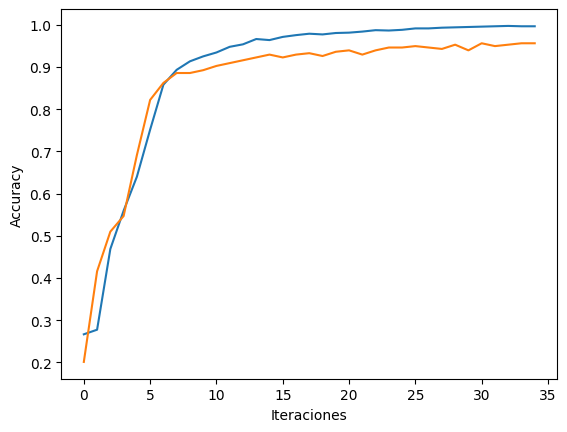

In [58]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Iteraciones')
plt.ylabel('Accuracy')
plt.show()

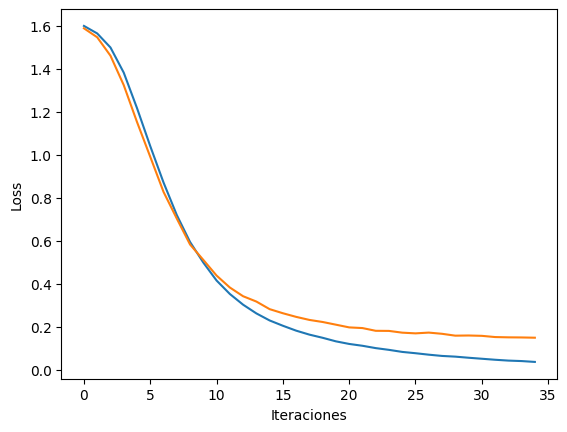

In [59]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.show()

In [66]:
clases = {
    0: 'Sport',
    1: 'Bussines',
    2: 'politics',
    3: 'entertainment',
    4: 'tech'
}

ejemplos = [
    "shares in the company fell in early trading after it said profits would be lower this year. analysts said the market reaction reflects concerns about future growth",
    "qpr keeper day heads for preston queens park rangers keeper chris day is set to join preston on a month s loan.  day has been displaced by the arrival of simon royce  who is in his second month on loan from charlton. qpr have also signed italian generoso rossi. r s manager ian holloway said:  some might say it s a risk as he can t be recalled during that month and simon royce can now be recalled by charlton.  but i have other irons in the fire. i have had a  yes  from a couple of others should i need them.   day s rangers contract expires in the summer. meanwhile  holloway is hoping to complete the signing of middlesbrough defender andy davies - either permanently or again on loan - before saturday s match at ipswich. davies impressed during a recent loan spell at loftus road. holloway is also chasing bristol city midfielder tom doherty",
    "the government said it will introduce new measures to improve public services. the minister said the policy aims to support economic growth and reduce unemployment",
    "technology firms said they are investing in new systems to improve services. the company said the platform will allow users to access data more quickly"
]

def predecirTexto(text):
    seq = tokenizer.texts_to_sequences(text)
    padded = pad_sequences(seq, maxlen=120, padding='post')
    pred = modelo.predict(padded)
    clase = pred.argmax(axis=1)[0]
    return clase, pred

for texto in ejemplos:
    clase, prob = predecirTexto(texto)
    print(f"texto: {texto}")
    print(f"Clase predicha: {clases[clase]}")
    print(f"Confianza : {prob.max()}")
    print("------------------------------------------------------------------------")



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
texto: shares in the company fell in early trading after it said profits would be lower this year. analysts said the market reaction reflects concerns about future growth
Clase predicha: Sport
Confianza : 0.9094122052192688
------------------------------------------------------------------------
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
texto: qpr keeper day heads for preston queens park rangers keeper chris day is set to join preston on a month s loan.  day has been displaced by the arrival of simon royce  who is in his second month on loan from charlton. qpr have also signed italian generoso rossi. r s manager ian holloway said:  some might say it s a risk as he can t be recalled during that month and simon royce can now be recalled by charlton.  but i have other irons in the fire. i have had a  yes  from a couple of others should i need them.   day s rangers contract expires in the summer. meanwhile  holloway is hoping to complete the signing of m